# panenAman — EDA & Modeling Ketahanan Pangan Jawa Timur
**Alur notebook:**
1. Load & validasi data
2. EDA — distribusi, tren, korelasi, heatmap status
3. Feature selection & preprocessing
4. Training model (Random Forest Classifier)
5. Evaluasi model
6. Simpan model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.inspection import permutation_importance
import joblib
import os

os.makedirs('output', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
})
C = {'Merah':'#f85149', 'Kuning':'#d29922', 'Hijau':'#3fb950',
     'blue':'#58a6ff', 'purple':'#bc8cff', 'muted':'#8b949e'}

print('Setup selesai ✓')

Setup selesai ✓


## 1. Load & Validasi Data

In [4]:
df = pd.read_csv('df_hist.csv')

status_map = {0: 'Hijau', 1: 'Kuning', 2: 'Merah'}
df['status'] = df['label_hist'].map(status_map)

print(f'Shape     : {df.shape}')
print(f'Kabupaten : {df.kabupaten.nunique()}')
print(f'Tahun     : {sorted(df.tahun.unique())}')
print(f'Kolom     : {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'Tidak ada')

print(f'\nDistribusi status:')
vc = df['label_hist'].value_counts()
for s, n in vc.items():
    status_label = status_map.get(s, str(s)) # Get string label, default to string conversion if not found
    print(f'  {status_label:8s}: {n:4d}  ({n/len(df)*100:.1f}%)')

df.head(3)

Shape     : (304, 33)
Kabupaten : 38
Tahun     : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Kolom     : ['kabupaten', 'tahun', 'luas_panen_ha', 'produktivitas_ku_ha', 'produktivitas_ton_ha', 'produksi_ton', 'suhu_mean', 'suhu_max_mean', 'suhu_min_mean', 'n_hari_panas', 'n_hari_dingin', 'hujan_total', 'hujan_mean_harian', 'n_hari_hujan', 'n_hari_kering', 'n_hari_ekstrim', 'hujan_max_harian', 'n_run2_hujan_ekstrim', 'n_run3_hujan_ekstrim', 'maks_run_hujan_ekstrim', 'n_run3_kering', 'n_run7_kering', 'maks_run_kering', 'et0_total', 'et0_mean', 'neraca_air', 'radiasi_mean', 'rh_max_mean', 'rh_min_mean', 'angin_max_mean', 'n_hari_angin_kencang', 'label_hist', 'status']

Missing values:
Series([], )

Distribusi status:
  Kuning  :  152  (50.0%)
  Merah   :   76  (25.0%)
  Hijau   :   76  (25.0%)


,kabupaten,tahun,luas_panen_ha,produktivitas_ku_ha,produktivitas_ton_ha,produksi_ton,suhu_mean,suhu_max_mean,suhu_min_mean,n_hari_panas,...,et0_total,et0_mean,neraca_air,radiasi_mean,rh_max_mean,rh_min_mean,angin_max_mean,n_hari_angin_kencang,label_hist,status
0,Pacitan,2018,19311.99,46.44,4.644,89684.44,25.984110,28.872055,23.788767,0,...,1385.52,3.795945,350.98,18.450986,92.865753,69.676712,16.994795,0,1,Kuning
1,Ponorogo,2018,63443.60,59.46,5.946,377263.18,27.003014,31.797260,23.543288,19,...,1745.90,4.783288,-542.50,19.649096,88.284932,52.994521,20.661918,0,2,Merah
2,Trenggalek,2018,22732.51,53.04,5.304,120574.63,25.311507,28.905753,22.769315,0,...,1313.24,3.597918,427.96,17.536000,95.161644,66.591781,14.147397,0,1,Kuning


## 2. EDA

### 2.1 Distribusi produktivitas per status

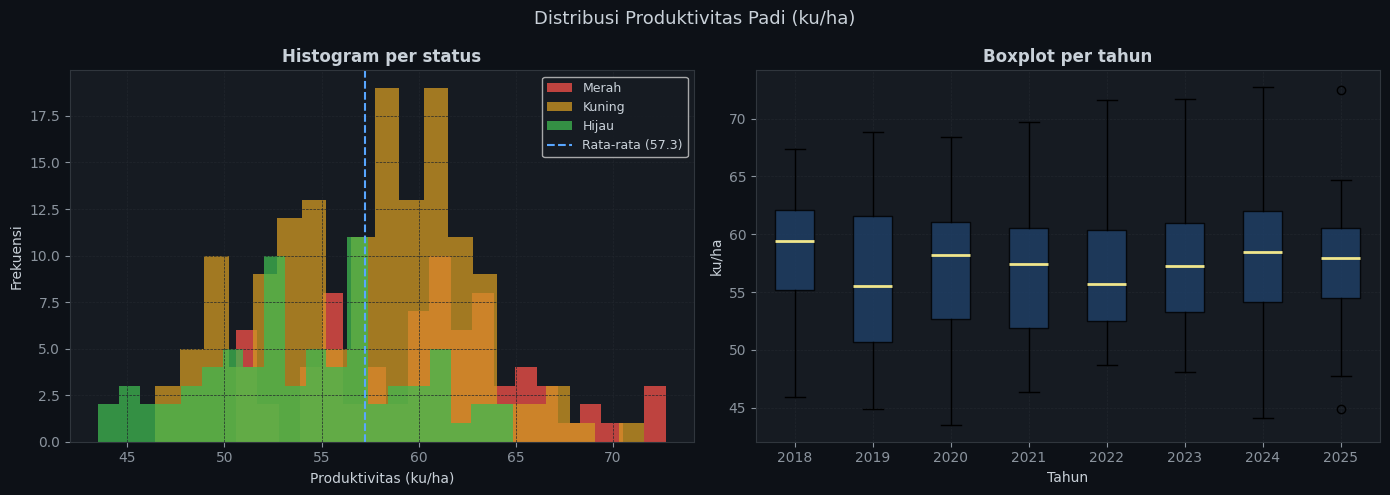

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Produktivitas Padi (ku/ha)', fontsize=13)

# Histogram per status
ax = axes[0]
for s in ['Merah', 'Kuning', 'Hijau']:
    ax.hist(df[df['status']==s]['produktivitas_ku_ha'],
            bins=20, alpha=0.75, color=C[s], label=s, edgecolor='none')
ax.axvline(df['produktivitas_ku_ha'].mean(), color=C['blue'],
           linestyle='--', linewidth=1.5, label=f'Rata-rata ({df["produktivitas_ku_ha"].mean():.1f})')
ax.set_xlabel('Produktivitas (ku/ha)')
ax.set_ylabel('Frekuensi')
ax.set_title('Histogram per status')
ax.legend(fontsize=9)
ax.grid(True)

# Boxplot per tahun
ax = axes[1]
years = sorted(df['tahun'].unique())
data_yr = [df[df['tahun']==y]['produktivitas_ku_ha'].values for y in years]
bp = ax.boxplot(data_yr, labels=years, patch_artist=True,
                medianprops=dict(color='#f0e68c', linewidth=2))
for p in bp['boxes']:
    p.set_facecolor('#1f4068'); p.set_alpha(0.8)
ax.set_xlabel('Tahun')
ax.set_ylabel('ku/ha')
ax.set_title('Boxplot per tahun')
ax.grid(True)

plt.tight_layout()
plt.savefig('output/eda_1_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Heatmap status per kabupaten × tahun

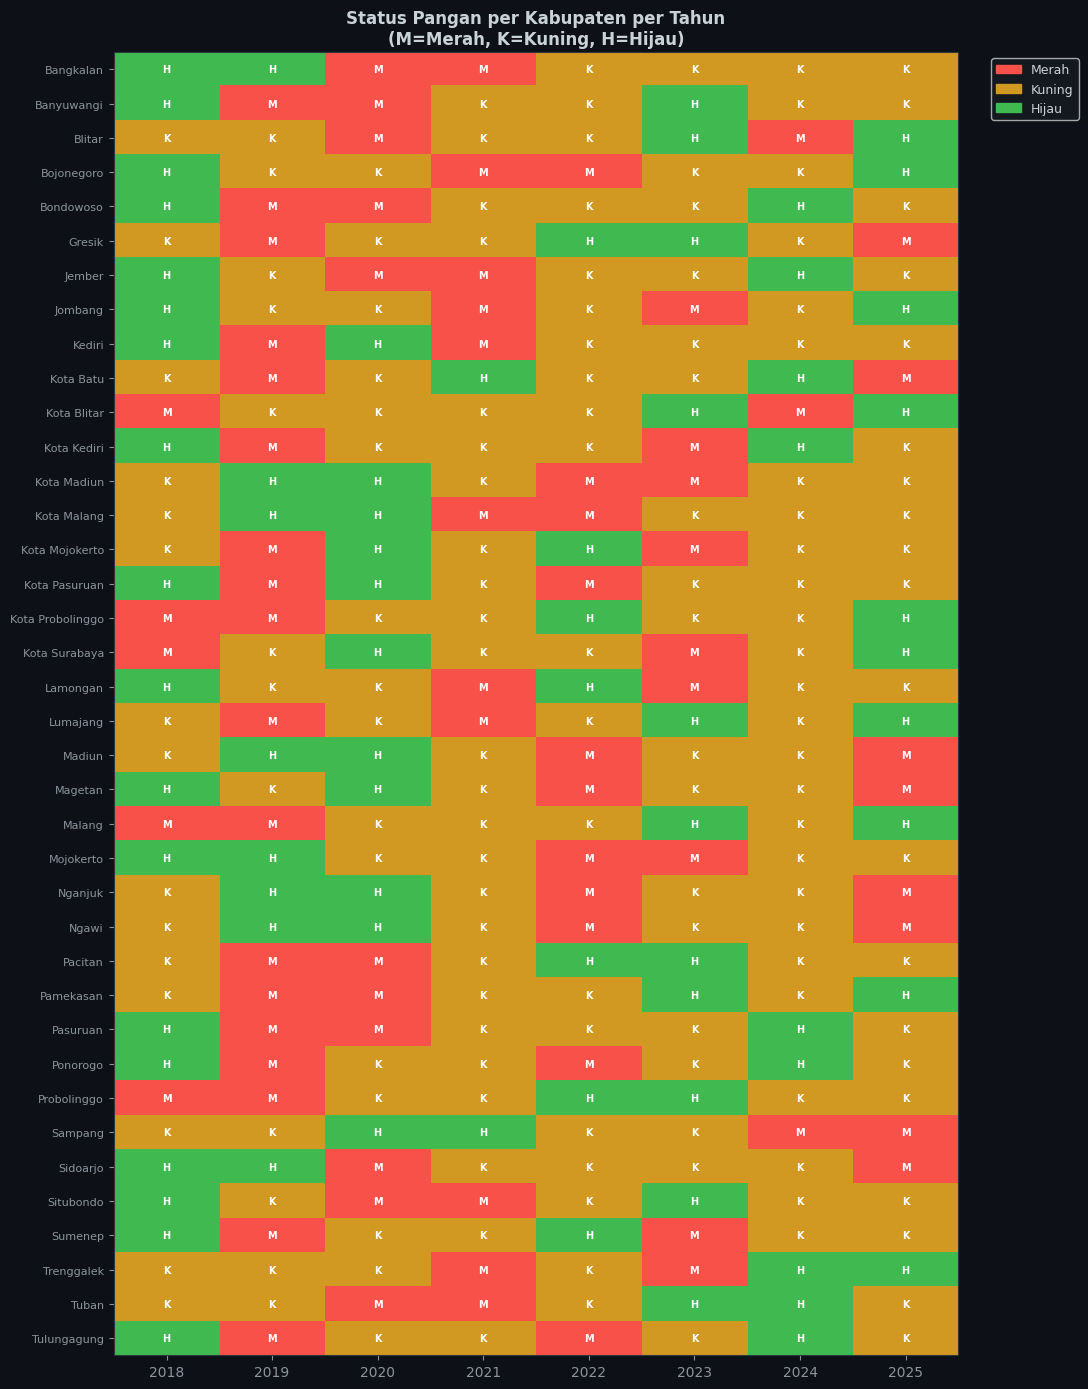

In [6]:
pivot = df.pivot_table(
    index='kabupaten', columns='tahun',
    values='label_hist', aggfunc='first'
)

fig, ax = plt.subplots(figsize=(11, 14))
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#f85149', '#d29922', '#3fb950'])
ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=0, vmax=2)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title('Status Pangan per Kabupaten per Tahun\n(M=Merah, K=Kuning, H=Hijau)', fontsize=12)

lbl = {0:'M', 1:'K', 2:'H'}
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, lbl[int(v)], ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

patches = [mpatches.Patch(color=C[s], label=s) for s in ['Merah','Kuning','Hijau']]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.15,1), fontsize=9)
plt.tight_layout()
plt.savefig('output/eda_2_heatmap_status.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Top 10 & Bottom 10 rata-rata produktivitas

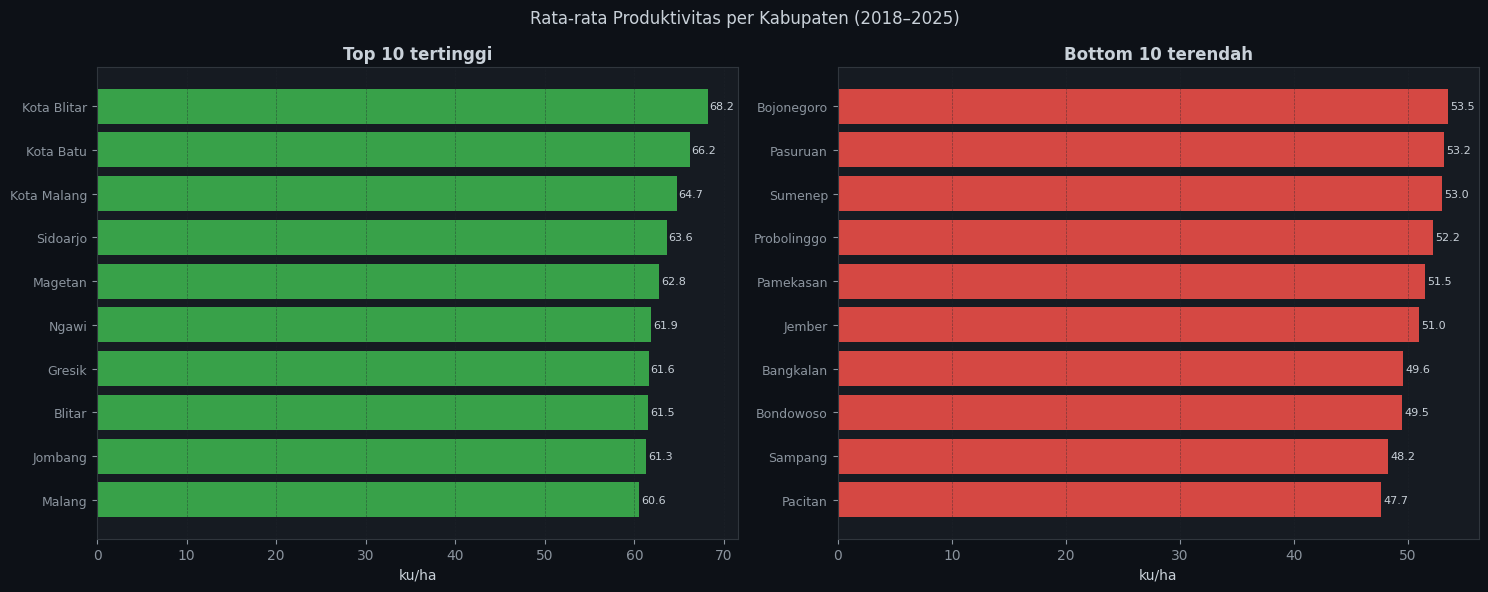

In [7]:
avg = df.groupby('kabupaten')['produktivitas_ku_ha'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Rata-rata Produktivitas per Kabupaten (2018–2025)', fontsize=12)

for ax, data, title, color in [
    (axes[0], avg.tail(10), 'Top 10 tertinggi', C['Hijau']),
    (axes[1], avg.head(10), 'Bottom 10 terendah', C['Merah']),
]:
    bars = ax.barh(range(len(data)), data.values, color=color, alpha=0.85, edgecolor='none')
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_xlabel('ku/ha')
    ax.set_title(title)
    ax.grid(True, axis='x', alpha=0.5)
    for i, v in enumerate(data.values):
        ax.text(v+0.2, i, f'{v:.1f}', va='center', fontsize=8, color='#c9d1d9')

plt.tight_layout()
plt.savefig('output/eda_3_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Korelasi fitur cuaca vs produktivitas

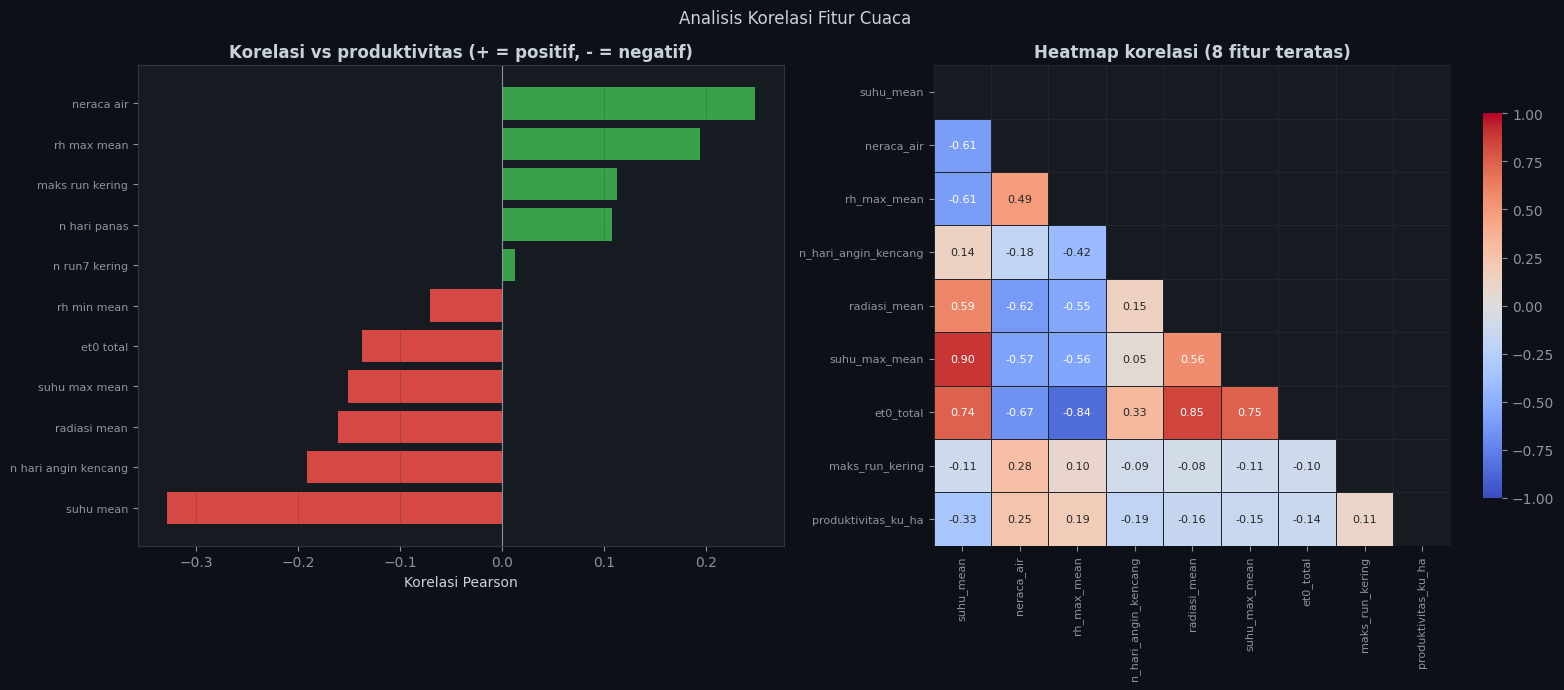


5 fitur paling berkorelasi dengan produktivitas:
suhu_mean               0.329
neraca_air              0.248
rh_max_mean             0.194
n_hari_angin_kencang    0.191
radiasi_mean            0.161


In [8]:
FITUR_CUACA = [
    'suhu_mean','suhu_max_mean','curah_hujan_total','hujan_harian_mean',
    'n_hari_hujan_lebat','n_run2_hujan','n_run3_hujan','maks_run_hujan',
    'n_run7_kering','maks_run_kering','neraca_air','et0_total',
    'radiasi_mean','rh_max_mean','rh_min_mean','n_hari_angin_kencang',
    'n_hari_panas'
]
FITUR_CUACA = [c for c in FITUR_CUACA if c in df.columns]

corr_target = (
    df[FITUR_CUACA + ['produktivitas_ku_ha']]
    .corr()['produktivitas_ku_ha']
    .drop('produktivitas_ku_ha')
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Korelasi Fitur Cuaca', fontsize=12)

# Bar korelasi
ax = axes[0]
colors_bar = [C['Merah'] if v < 0 else C['Hijau'] for v in corr_target.values]
ax.barh(range(len(corr_target)), corr_target.values, color=colors_bar, alpha=0.85, edgecolor='none')
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels([c.replace('_',' ') for c in corr_target.index], fontsize=8)
ax.axvline(0, color=C['muted'], linewidth=0.8)
ax.set_xlabel('Korelasi Pearson')
ax.set_title('Korelasi vs produktivitas (+ = positif, - = negatif)')
ax.grid(True, axis='x', alpha=0.4)

# Heatmap korelasi antar fitur
ax = axes[1]
TOP_FITUR = corr_target.abs().sort_values(ascending=False).head(8).index.tolist()
corr_mat = df[TOP_FITUR + ['produktivitas_ku_ha']].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, ax=ax,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size':8},
    linewidths=0.4, linecolor='#21262d',
    cbar_kws={'shrink':0.8}
)
ax.set_title('Heatmap korelasi (8 fitur teratas)')
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.savefig('output/eda_4_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n5 fitur paling berkorelasi dengan produktivitas:')
print(corr_target.abs().sort_values(ascending=False).head(5).round(3).to_string())

### 2.5 Tren produktivitas — 6 kabupaten sampel

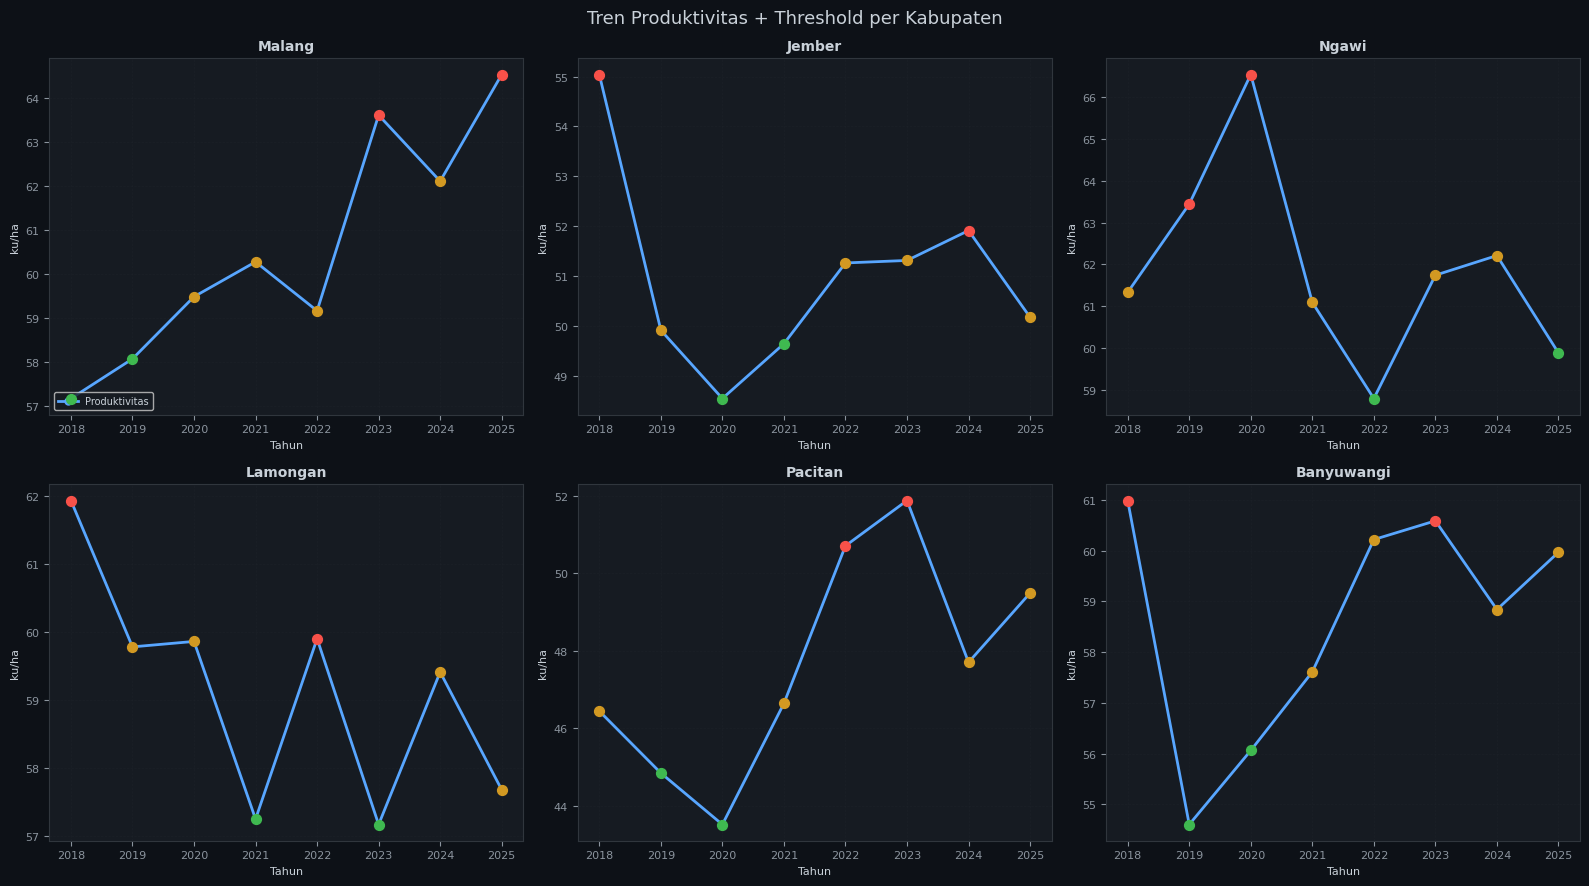

In [9]:
SAMPEL = ['Malang','Jember','Ngawi','Lamongan','Pacitan','Banyuwangi']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Tren Produktivitas + Threshold per Kabupaten', fontsize=13)

for ax, kab in zip(axes.flat, SAMPEL):
    sub = df[df['kabupaten']==kab].sort_values('tahun')
    bl  = sub['baseline'].iloc[0] if 'baseline' in sub.columns else None
    bm  = sub['batas_merah'].iloc[0] if 'batas_merah' in sub.columns else None
    q1  = sub['q1'].iloc[0] if 'q1' in sub.columns else None
    q3  = sub['q3'].iloc[0] if 'q3' in sub.columns else None

    ax.plot(sub['tahun'], sub['produktivitas_ku_ha'], 'o-',
            color=C['blue'], linewidth=2, markersize=5, zorder=5, label='Produktivitas')

    # Warnai titik sesuai status
    for _, row in sub.iterrows():
        col = C.get(row['status'], C['blue'])
        ax.scatter(row['tahun'], row['produktivitas_ku_ha'], color=col, s=50, zorder=6)

    if bl is not None:
        ax.axhline(bl, color=C['purple'], linestyle='-', linewidth=1.5, alpha=0.9, label=f'Baseline {bl:.1f}')
    if bm is not None:
        ax.axhline(bm, color=C['Merah'], linestyle='--', linewidth=1.5, alpha=0.9, label=f'Batas merah {bm:.1f}')
    if q1 is not None and q3 is not None:
        ax.axhspan(q1, q3, alpha=0.08, color='#d29922')

    ax.set_title(kab, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tahun', fontsize=8)
    ax.set_ylabel('ku/ha', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.4)
    if kab == SAMPEL[0]:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.savefig('output/eda_5_tren_kabupaten.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Selection & Preprocessing

In [10]:
# Fitur X yang dipakai untuk training
FITUR_X = [
    'suhu_mean','suhu_max_mean','suhu_min_mean',
    'curah_hujan_total','hujan_harian_mean',
    'n_hari_hujan_lebat','n_run2_hujan','n_run3_hujan','maks_run_hujan',
    'n_run7_kering','maks_run_kering',
    'neraca_air','et0_total','et0_mean',
    'radiasi_mean','rh_max_mean','rh_min_mean',
    'angin_max_mean','n_hari_angin_kencang',
    'n_hari_panas','luas_panen_ha'
]
# Hanya pakai kolom yang ada
FITUR_X = [c for c in FITUR_X if c in df.columns]

TARGET = 'status'  # Merah / Kuning / Hijau

# Drop baris yang ada missing di fitur
df_model = df[FITUR_X + [TARGET, 'kabupaten', 'tahun']].dropna().copy()

X = df_model[FITUR_X].values
y = df_model[TARGET].values
groups = df_model['tahun'].values  # untuk Leave-One-Year-Out CV

print(f'Dataset modeling: {X.shape}')
print(f'Fitur X: {len(FITUR_X)}')
print(f'Distribusi label Y: {pd.Series(y).value_counts().to_dict()}')
print(f'Fitur: {FITUR_X}')

Dataset modeling: (304, 15)
Fitur X: 15
Distribusi label Y: {'Kuning': 152, 'Merah': 76, 'Hijau': 76}
Fitur: ['suhu_mean', 'suhu_max_mean', 'suhu_min_mean', 'n_run7_kering', 'maks_run_kering', 'neraca_air', 'et0_total', 'et0_mean', 'radiasi_mean', 'rh_max_mean', 'rh_min_mean', 'angin_max_mean', 'n_hari_angin_kencang', 'n_hari_panas', 'luas_panen_ha']


## 4. Training Model — Random Forest Classifier

In [11]:
logo = LeaveOneGroupOut()
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf, X, y, groups=groups,
    cv=logo, scoring='accuracy'
)

print(f'Leave-One-Year-Out CV Accuracy:')
for tahun, score in zip(sorted(df_model['tahun'].unique()), cv_scores):
    print(f'  Test tahun {tahun}: {score:.3f}')
print(f'\nRata-rata: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Leave-One-Year-Out CV Accuracy:
  Test tahun 2018: 0.368
  Test tahun 2019: 0.237
  Test tahun 2020: 0.342
  Test tahun 2021: 0.368
  Test tahun 2022: 0.447
  Test tahun 2023: 0.263
  Test tahun 2024: 0.526
  Test tahun 2025: 0.263

Rata-rata: 0.352 ± 0.093


In [12]:
rf.fit(X, y)

y_pred = rf.predict(X)
print('=== Training Performance (in-sample) ===')
print(classification_report(y, y_pred, target_names=['Hijau','Kuning','Merah']))

joblib.dump(rf, 'output/model_rf_panenaman.pkl')
joblib.dump(FITUR_X, 'output/fitur_x.pkl')
print('\nModel tersimpan: output/model_rf_panenaman.pkl')

=== Training Performance (in-sample) ===
              precision    recall  f1-score   support

       Hijau       0.99      0.99      0.99        76
      Kuning       0.98      0.97      0.98       152
       Merah       0.96      0.97      0.97        76

    accuracy                           0.98       304
   macro avg       0.98      0.98      0.98       304
weighted avg       0.98      0.98      0.98       304


Model tersimpan: output/model_rf_panenaman.pkl


## 5. Evaluasi Model

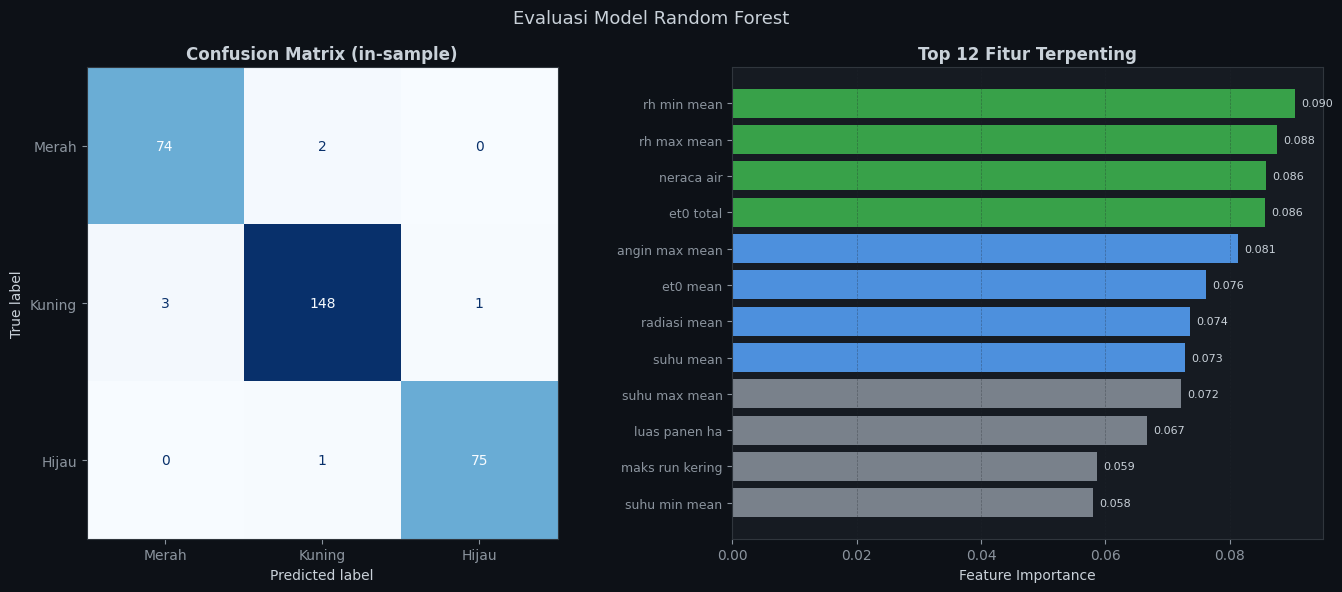


Top 5 fitur terpenting:
rh_min_mean       0.0904
rh_max_mean       0.0876
neraca_air        0.0859
et0_total         0.0857
angin_max_mean    0.0813


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evaluasi Model Random Forest', fontsize=13)

# Confusion matrix
ax = axes[0]
labels = ['Merah','Kuning','Hijau']
cm = confusion_matrix(y, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (in-sample)')
ax.set_facecolor('#161b22')

# Feature importance
ax = axes[1]
importances = pd.Series(rf.feature_importances_, index=FITUR_X).sort_values(ascending=False).head(12)
bar_colors = [C['Hijau'] if i < 4 else C['blue'] if i < 8 else C['muted']
              for i in range(len(importances))]
ax.barh(range(len(importances)), importances.values[::-1],
        color=bar_colors[::-1], alpha=0.85, edgecolor='none')
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([f.replace('_',' ') for f in importances.index[::-1]], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 12 Fitur Terpenting')
ax.grid(True, axis='x', alpha=0.4)
for i, v in enumerate(importances.values[::-1]):
    ax.text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8, color='#c9d1d9')

plt.tight_layout()
plt.savefig('output/eda_6_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 5 fitur terpenting:')
print(importances.head(5).round(4).to_string())

In [17]:
print('=' * 55)
print('RINGKASAN MODEL & REKOMENDASI DEPLOYMENT')
print('=' * 55)
print(f'''
Model    : Random Forest Classifier
Fitur X  : {len(FITUR_X)} kolom cuaca + luas panen
Target Y : status (Merah / Kuning / Hijau)
CV       : Leave-One-Year-Out (validasi time series)
CV Acc   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}

''')

import os
for f in sorted(os.listdir('output')):
    print(f'  {f}')

RINGKASAN MODEL & REKOMENDASI DEPLOYMENT

Model    : Random Forest Classifier
Fitur X  : 15 kolom cuaca + luas panen
Target Y : status (Merah / Kuning / Hijau)
CV       : Leave-One-Year-Out (validasi time series)
CV Acc   : 0.352 ± 0.093


  eda_1_distribusi.png
  eda_2_heatmap_status.png
  eda_3_ranking.png
  eda_4_korelasi.png
  eda_5_tren_kabupaten.png
  eda_6_model_eval.png
  fitur_x.pkl
  model_rf_panenaman.pkl


In [18]:
!zip -r sipadi.zip output/

  adding: output/ (stored 0%)
  adding: output/eda_5_tren_kabupaten.png (deflated 12%)
  adding: output/eda_6_model_eval.png (deflated 14%)
  adding: output/eda_4_korelasi.png (deflated 11%)
  adding: output/model_rf_panenaman.pkl (deflated 77%)
  adding: output/fitur_x.pkl (deflated 40%)
  adding: output/eda_2_heatmap_status.png (deflated 21%)
  adding: output/eda_3_ranking.png (deflated 18%)
  adding: output/eda_1_distribusi.png (deflated 12%)
